In [8]:
import numpy as np
import pickle

file = open('data/TEST_DIVERSE_2.pkl','rb')
data = pickle.load(file)
file.close()
last_values = data[:, :, -1]  # Shape: (39732, 7)

# Step 2: Get sorting indices for descending order
sorted_indices = np.argsort(-last_values, axis=1)  # Shape: (39732, 7)

# Step 3: Reorder the curves within each family
# Use advanced indexing to reorder curves according to sorted_indices
reordered_curves = np.take_along_axis(data, sorted_indices[:, :, np.newaxis], axis=1)


dumpfile = open('data/MARIO_ORDERED_TEST.pkl','wb')
pickle.dump(reordered_curves,dumpfile)
dumpfile.close()

In [ ]:
import numpy as np
import pickle

# Load data
with open('data/TEST_DIVERSE_4.pkl', 'rb') as file:
    data = pickle.load(file)  # shape: (x, 7, 129)

# Compute max value for each curve (axis=2 is the time dimension)
max_values = np.max(data, axis=2)  # shape: (x, 7)

# Get sorting indices in descending order of max values
sorted_indices = np.argsort(-max_values, axis=1)  # shape: (x, 7)

# Reorder curves according to those indices
# Expand sorted_indices to match data's shape for advanced indexing
reordered = np.take_along_axis(data, sorted_indices[:, :, np.newaxis], axis=1)

# Save the reordered data
with open('data/NEW_ORDERED_TEST_START.pkl', 'wb') as dumpfile:
    pickle.dump(reordered, dumpfile)

In [3]:
import numpy as np
import pickle

# --- Input and Output File Paths ---
# It's good practice to define file paths at the top
input_file = 'data/TRAIN_DIVERSE_4.pkl'
output_file = 'data/TRAIN_ORDERED_DOWNSAMPLED.pkl' # New descriptive name

# Load data
print(f"Loading data from {input_file}...")
with open(input_file, 'rb') as file:
    data = pickle.load(file)  # shape: (x, 7, 129)

# --- 1. Reorder species based on max population (your original logic) ---
# Compute max value for each curve (axis=2 is the time dimension)
max_values = np.max(data, axis=2)  # shape: (x, 7)

# Get sorting indices in descending order of max values
sorted_indices = np.argsort(-max_values, axis=1)  # shape: (x, 7)

# Reorder curves according to those indices
reordered = np.take_along_axis(data, sorted_indices[:, :, np.newaxis], axis=1)  # shape: (x, 7, 129)
print(f"Original shape after reordering species: {reordered.shape}")

# --- 2. Downsample the time series dimension ---
# Take every other data point along the time axis (axis=2)
print("Downsampling time series from 129 to 65 points...")
downsampled = reordered[:, :, ::2]
print(f"New downsampled shape: {downsampled.shape}")

# Verify the length
assert downsampled.shape[2] == 65, "Downsampled length is not 65!"


# --- 3. Save the final processed data ---
# Save the new downsampled data
print(f"Saving processed data to {output_file}...")
with open(output_file, 'wb') as dumpfile:
    pickle.dump(downsampled, dumpfile)

print("Done.")

Loading data from data/TRAIN_DIVERSE_4.pkl...
Original shape after reordering species: (79018, 7, 129)
Downsampling time series from 129 to 65 points...
New downsampled shape: (79018, 7, 65)
Saving processed data to data/TRAIN_ORDERED_DOWNSAMPLED.pkl...
Done.


Data shape: (79018, 7, 65)


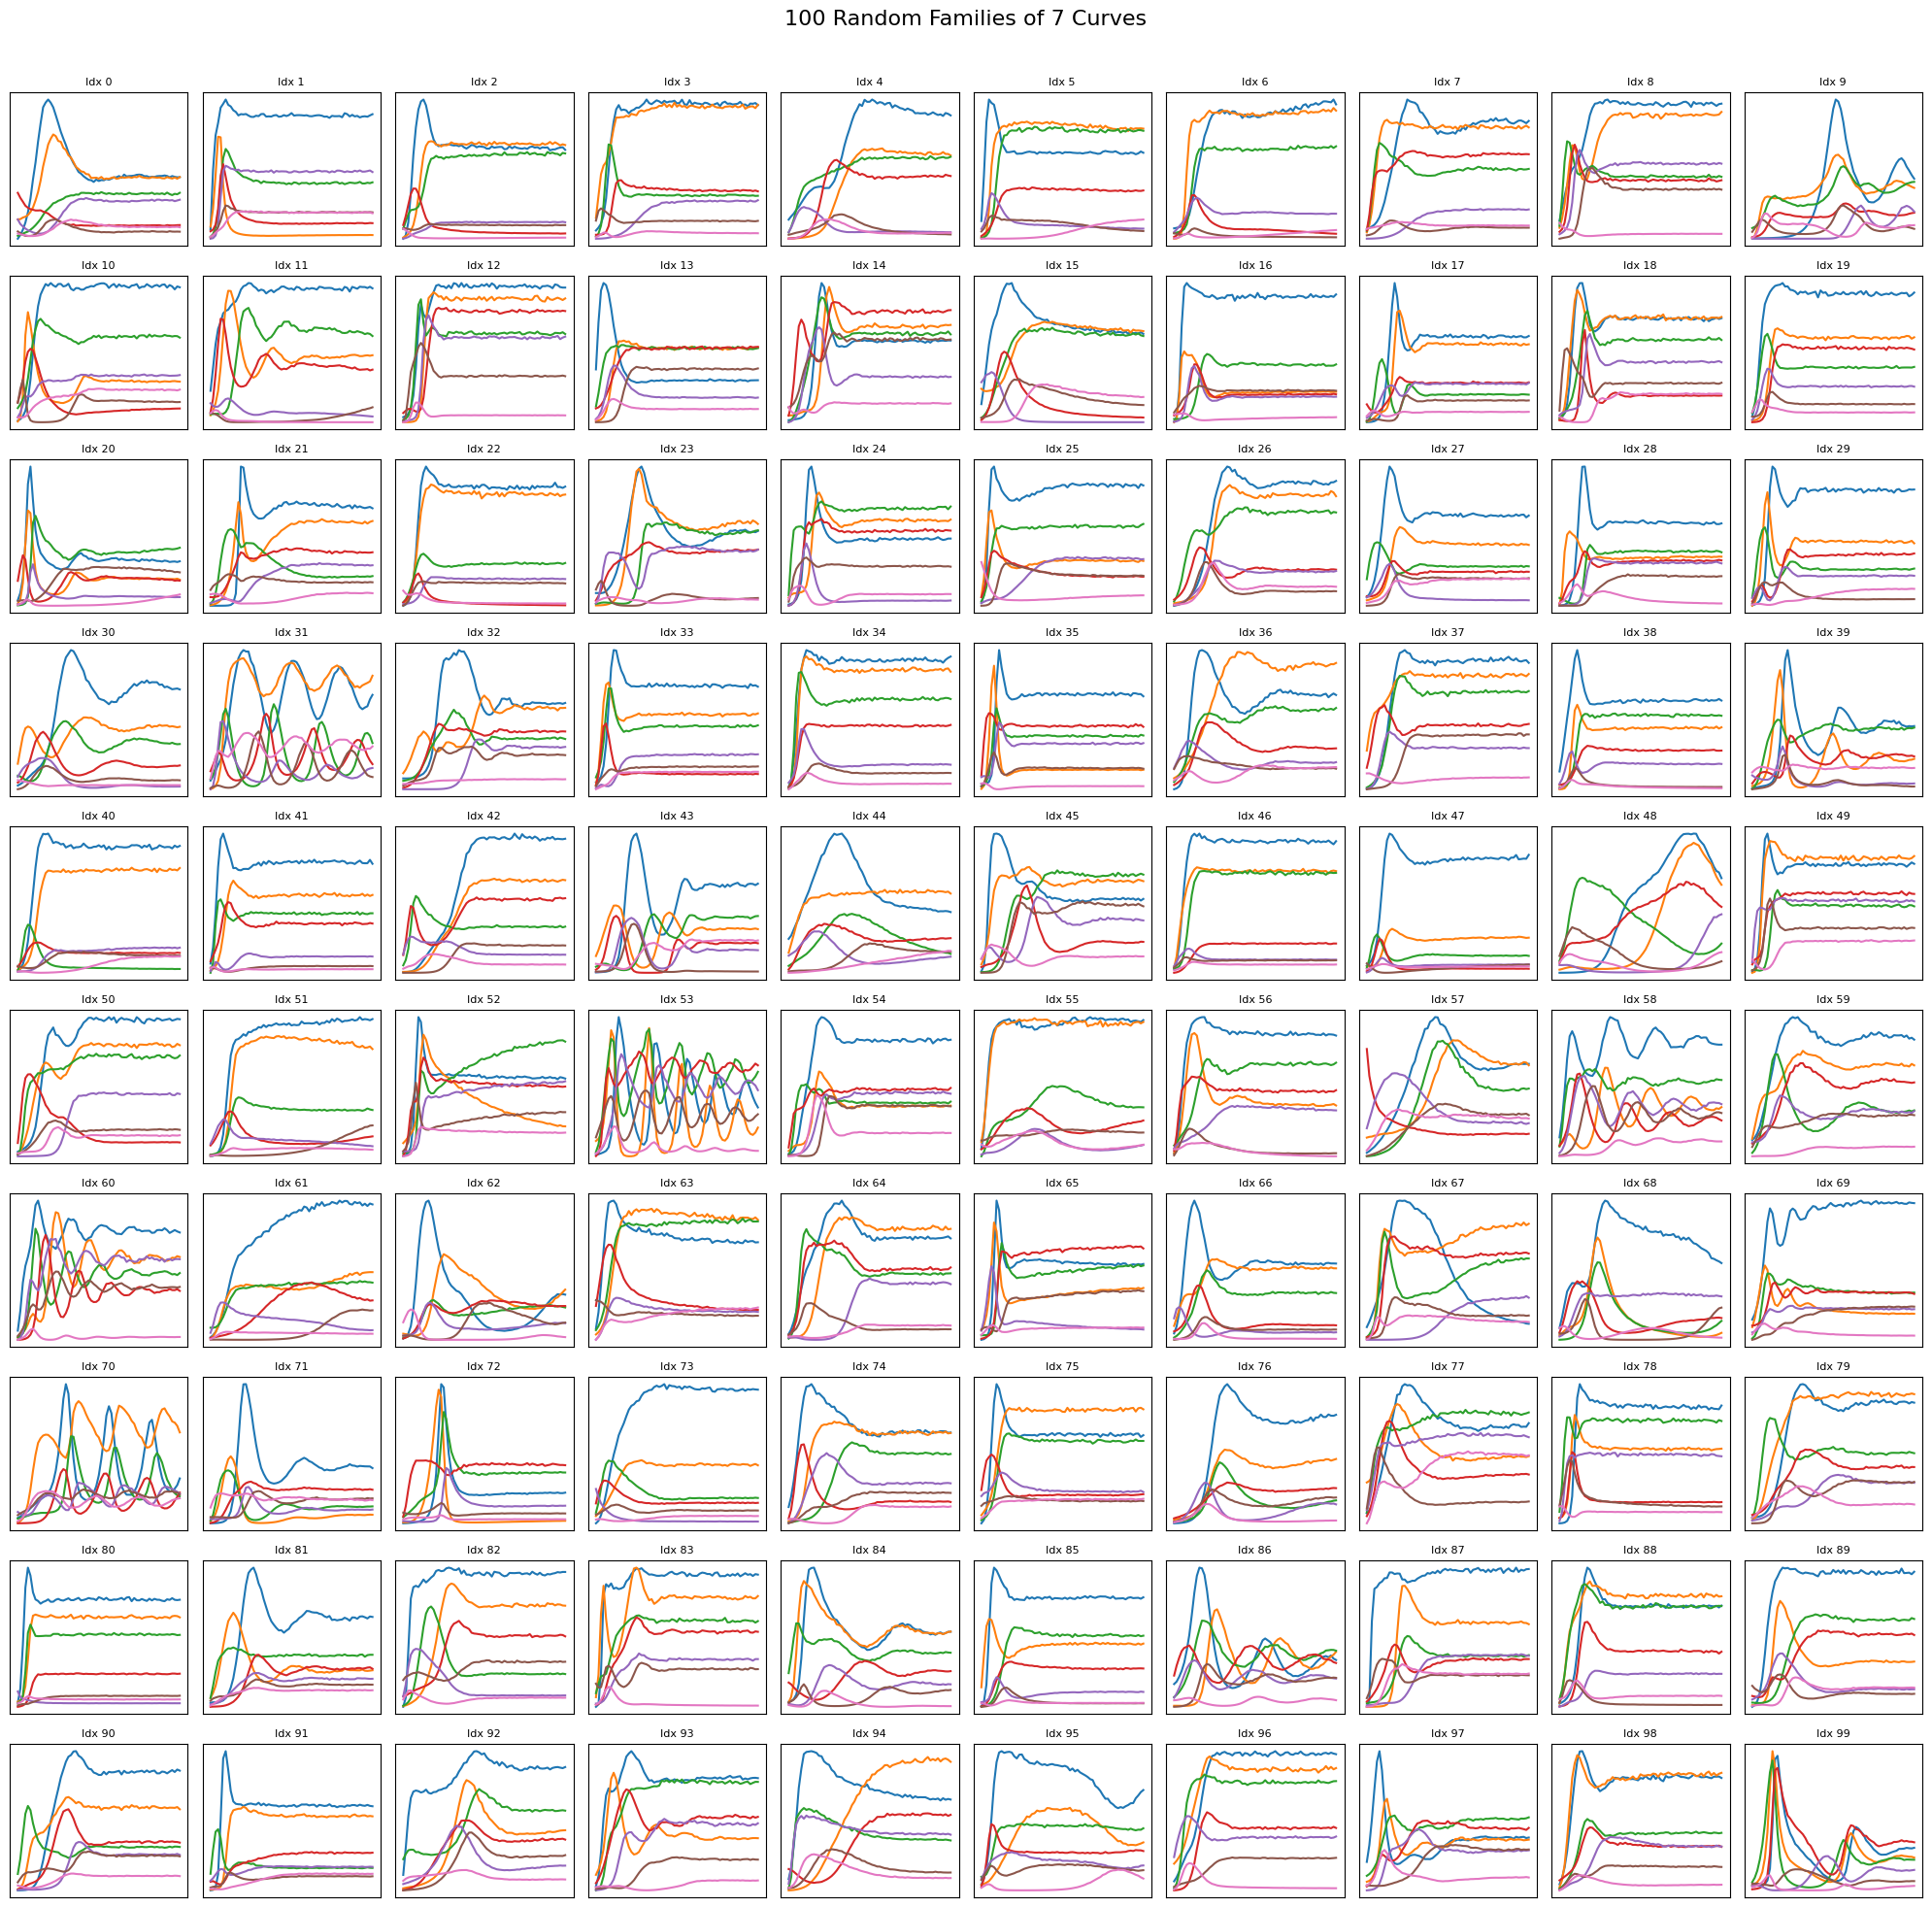

In [4]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# Load the data
with open('data/TRAIN_ORDERED_DOWNSAMPLED.pkl', 'rb') as file:
    data = pickle.load(file)  # shape (N, 7, 129)

# Confirm the shape
print("Data shape:", data.shape)

# Get random indices for 100 families
N = data.shape[0]
random_indices = list(range(100))
subset = data[random_indices]  # shape (100, 7, 129)

# Plot setup
fig, axes = plt.subplots(10, 10, figsize=(20, 20))
fig.suptitle('100 Random Families of 7 Curves', fontsize=16)

axes = axes.flatten()
for i in range(100):
    ax = axes[i]
    for j in range(7):
        ax.plot(subset[i][j])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'Idx {random_indices[i]}', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

0.08893581690236825


Text(0.5, 1.0, 'Máximo valor normalizado por familia')

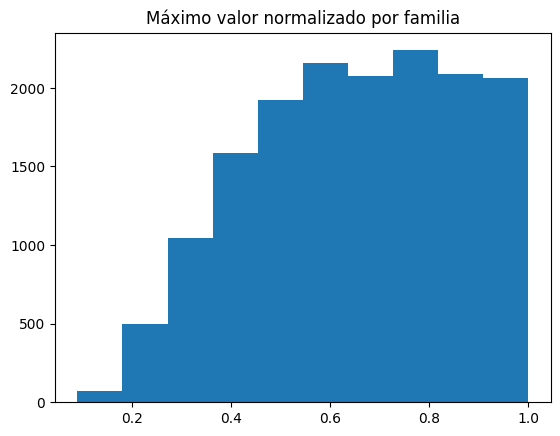

In [2]:
import numpy as np
import pickle
import matplotlib.pyplot as plt


# Load data
with open('data/TEST_DIVERSE_4.pkl', 'rb') as file:
    data = pickle.load(file)  # shape: (x, 7, 129)

data = (data - data.min()) / (data.max() - data.min())
# Compute max value for each curve (axis=2 is the time dimension)
max_values = np.max(data, axis=2)  # shape: (x, 7)

max_values2 = np.max(max_values, axis=1)

print(max_values2.min())

plt.hist(max_values2)
plt.title('Máximo valor normalizado por familia')

In [1]:
import pickle


TRAIN_ROUTE = 'data/TRAIN_PREPROCESSED_DS.pkl'

print(f"Loading data from '{TRAIN_ROUTE}'...")
with open(TRAIN_ROUTE, 'rb') as f:
    # We assume the data is a list of objects, where each object
    # represents one "family" of curves.
    all_families_data = pickle.load(f)



Loading data from 'data/TRAIN_PREPROCESSED_DS.pkl'...


In [4]:
all_families_data.keys()

dict_keys(['data', 'reconstruction_max_values', 'family_max_values'])

In [6]:
all_families_data['data'].shape

(79018, 7, 65)

Loading data from 'data/TRAIN_PREPROCESSED_DS.pkl'...
Data loaded. Total families: 79018. Analyzing: 1000.

--- Starting Analysis on 1000 Families ---
  ... processing family 100/1000
  ... processing family 200/1000
  ... processing family 300/1000


  ... processing family 400/1000
  ... processing family 500/1000
  ... processing family 600/1000
  ... processing family 700/1000
  ... processing family 800/1000
  ... processing family 900/1000
  ... processing family 1000/1000
--- Analysis Complete ---


--- Overall Dataset Quality Report ---
Statistics for Average Family R² Scores (across 1000 families):
  - Mean:   0.9872
  - Median: 0.9910
  - Std Dev:0.0130
  - Min:    0.8499 (Family #160)
  - Max:    0.9979 (Family #385)

Found 2 families with an average R² score below the threshold of 0.9:
  - Family #160 -> Average R² = 0.8499
  - Family #576 -> Average R² = 0.8535


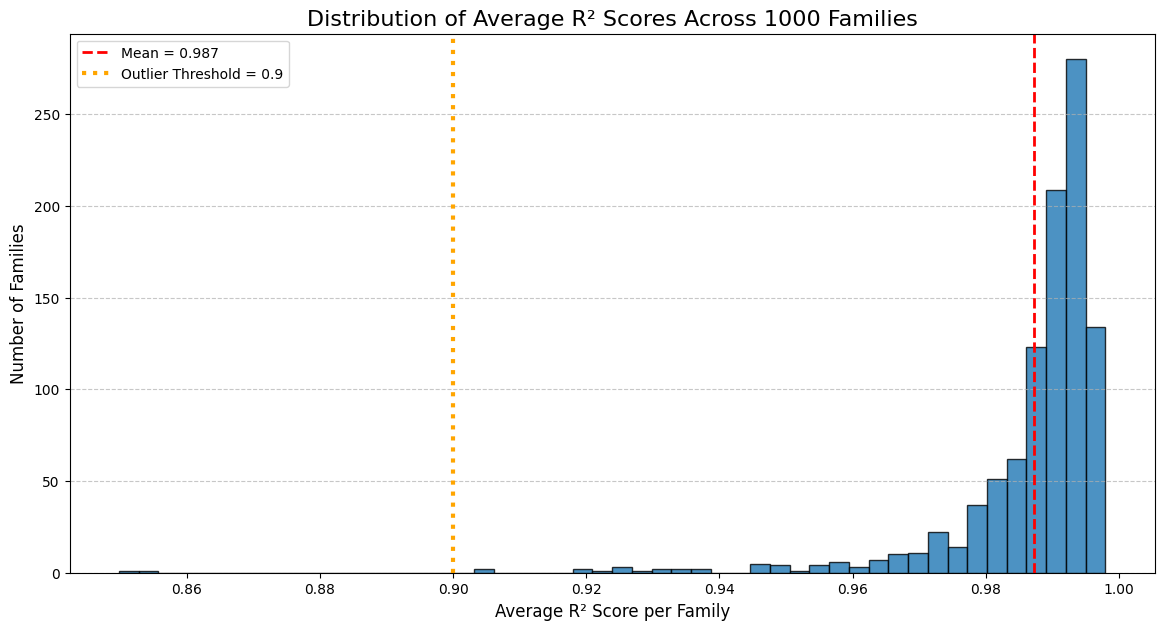

In [9]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os
import warnings

# --- 1. SETUP and DATA LOADING ---

TRAIN_ROUTE = 'data/TRAIN_PREPROCESSED_DS.pkl'

# --- CONFIGURATION ---
# Set the number of families to analyze. 
# Set to -1 to analyze ALL families (can be slow!).
FAMILIES_TO_ANALYZE = 1000 # Let's analyze 1000 families for a good sample.

# Set a threshold for identifying "outlier" or "poor fit" families.
# A family with an average R² below this value will be flagged.
OUTLIER_R2_THRESHOLD = 0.90

if not os.path.exists(TRAIN_ROUTE):
    print(f"Error: The file was not found at '{TRAIN_ROUTE}'")
    exit()

print(f"Loading data from '{TRAIN_ROUTE}'...")
with open(TRAIN_ROUTE, 'rb') as f:
    loaded_data = pickle.load(f)

# --- 2. DATA PREPARATION ---

data_cube = loaded_data['data']
max_values_cube = loaded_data['reconstruction_max_values']
N_FAMILIES_TOTAL, N_SPECIES, N_TIMEPOINTS = data_cube.shape
t = np.arange(N_TIMEPOINTS)

if FAMILIES_TO_ANALYZE == -1 or FAMILIES_TO_ANALYZE > N_FAMILIES_TOTAL:
    families_to_process = N_FAMILIES_TOTAL
else:
    families_to_process = FAMILIES_TO_ANALYZE

print(f"Data loaded. Total families: {N_FAMILIES_TOTAL}. Analyzing: {families_to_process}.")


# --- 3. ANALYSIS FUNCTION (same as before) ---

def test_lv_fit(x_data, t):
    N = x_data.shape[1]
    r2_scores = []
    
    for i in range(N):
        x_i_positive = np.maximum(x_data[:, i], 1e-9)
        log_xi = np.log(x_i_positive)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            d_log_xi_dt = np.gradient(log_xi, t)

        model = LinearRegression()
        model.fit(x_data, d_log_xi_dt)
        
        predicted_growth_rate = model.predict(x_data)
        r2 = r2_score(d_log_xi_dt, predicted_growth_rate)
        r2_scores.append(r2)
        
    return np.array(r2_scores)

# --- 4. PROCESS ALL FAMILIES AND COLLECT METRICS ---

# This list will store the average R² for each family
family_avg_r2_scores = []

print(f"\n--- Starting Analysis on {families_to_process} Families ---")
for i in range(families_to_process):
    # Optional: Print progress every 100 families
    if (i + 1) % 100 == 0:
        print(f"  ... processing family {i+1}/{families_to_process}")
        
    unscaled_family_data = data_cube[i, :, :]
    max_vals_for_family = max_values_cube[i]
    x_data_rescaled = unscaled_family_data.T * max_vals_for_family
    
    # Run the LV test and get the 7 R² scores for this family
    r2_scores_for_family = test_lv_fit(x_data_rescaled, t)
    
    # Calculate the average R² and store it
    avg_r2 = np.mean(r2_scores_for_family)
    family_avg_r2_scores.append(avg_r2)

print("--- Analysis Complete ---")

# Convert list to a NumPy array for easier calculations
family_avg_r2_scores = np.array(family_avg_r2_scores)


# --- 5. OVERALL SUMMARY REPORT AND VISUALIZATION ---

print("\n\n--- Overall Dataset Quality Report ---")

# Calculate key statistics
mean_of_averages = np.mean(family_avg_r2_scores)
median_of_averages = np.median(family_avg_r2_scores)
std_dev = np.std(family_avg_r2_scores)
min_avg_r2 = np.min(family_avg_r2_scores)
max_avg_r2 = np.max(family_avg_r2_scores)

print(f"Statistics for Average Family R² Scores (across {families_to_process} families):")
print(f"  - Mean:   {mean_of_averages:.4f}")
print(f"  - Median: {median_of_averages:.4f}")
print(f"  - Std Dev:{std_dev:.4f}")
print(f"  - Min:    {min_avg_r2:.4f} (Family #{np.argmin(family_avg_r2_scores)})")
print(f"  - Max:    {max_avg_r2:.4f} (Family #{np.argmax(family_avg_r2_scores)})")

# Identify and report outliers
outlier_indices = np.where(family_avg_r2_scores < OUTLIER_R2_THRESHOLD)[0]
num_outliers = len(outlier_indices)

print(f"\nFound {num_outliers} families with an average R² score below the threshold of {OUTLIER_R2_THRESHOLD}:")
if num_outliers > 0:
    # Print the first 10 outliers for brevity
    for k, idx in enumerate(outlier_indices):
        if k < 10:
            print(f"  - Family #{idx} -> Average R² = {family_avg_r2_scores[idx]:.4f}")
        elif k == 10:
            print(f"  ... and {num_outliers - 10} more.")
            break
else:
    print("  - None. All analyzed families meet the quality threshold.")


# Create the histogram visualization
plt.figure(figsize=(14, 7))
plt.hist(family_avg_r2_scores, bins=50, edgecolor='black', alpha=0.8)

# Add lines for mean and the outlier threshold for context
plt.axvline(mean_of_averages, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_of_averages:.3f}')
plt.axvline(OUTLIER_R2_THRESHOLD, color='orange', linestyle=':', linewidth=3, label=f'Outlier Threshold = {OUTLIER_R2_THRESHOLD}')

plt.title(f'Distribution of Average R² Scores Across {families_to_process} Families', fontsize=16)
plt.xlabel('Average R² Score per Family', fontsize=12)
plt.ylabel('Number of Families', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


all_families_data

--- Loading Neural Network Model ---
Using device: cuda
VAE Parameters: Latent Dim=40, Num Curves=7
LSTM Parameters: Hidden Size=256, Num Layers=2

--- Generating 1000 new samples from the model ---
Generation complete.

--- Starting LV Analysis on 1000 generated families ---
  ... processing family 100/1000


  ... processing family 200/1000
  ... processing family 300/1000
  ... processing family 400/1000
  ... processing family 500/1000
  ... processing family 600/1000
  ... processing family 700/1000
  ... processing family 800/1000
  ... processing family 900/1000
  ... processing family 1000/1000
--- Analysis Complete ---


--- Overall Quality Report for Data Generated by NN Model ---
Statistics for Average Family R² Scores (across 1000 families):
  - Mean:   0.9551
  - Median: 0.9854
  - Min:    0.6396 (Family #587)

Found 175 families with an avg R² < 0.9


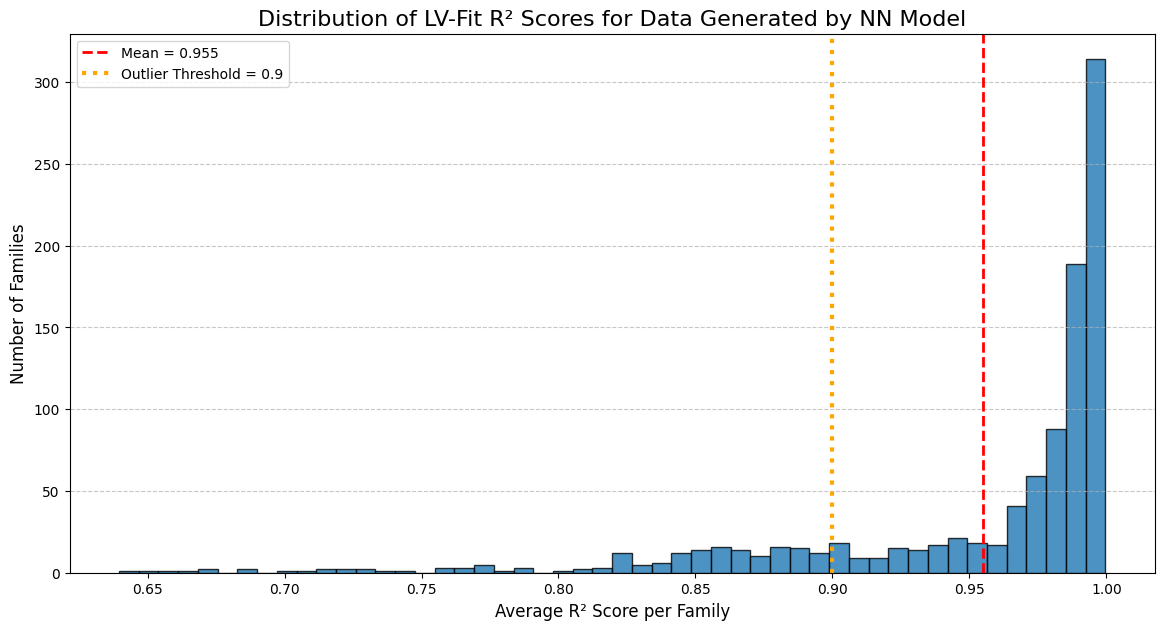

In [5]:
# file: test_generated_data.py

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import os
import warnings

# The only change needed: import the class from your models.py file
from VAE.models.cvae import LSTM_VAE
from config import model_config
# --- CONFIGURATION ---
# (This section remains exactly the same)
MODEL_SAVE_ROUTE = './model_ckpts/'
MODEL_NAME = "model_new_arch"
# ... etc.
# !! IMPORTANT !! These values MUST match the architecture of the saved model.

CHECKPOINT_PATH = os.path.join(MODEL_SAVE_ROUTE, f"{MODEL_NAME}.pth")
NUM_SAMPLES_TO_GENERATE = 1000
OUTLIER_R2_THRESHOLD = 0.90
t_time_array = 65


# --- ANALYSIS FUNCTION ---
# (This function remains exactly the same)
def test_lv_fit(x_data, t):
    """Performs the Lotka-Volterra linear regression test on a single family."""
    N = x_data.shape[1]
    r2_scores = []
    
    for i in range(N):
        x_i_positive = np.maximum(x_data[:, i], 1e-9)
        log_xi = np.log(x_i_positive)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            d_log_xi_dt = np.gradient(log_xi, t)

        model = LinearRegression()
        model.fit(x_data, d_log_xi_dt)
        predicted_growth_rate = model.predict(x_data)
        r2 = r2_score(d_log_xi_dt, predicted_growth_rate)
        r2_scores.append(r2)
        
    return np.array(r2_scores)


# --- MAIN EXECUTION SCRIPT ---
# (This section remains exactly the same)
if __name__ == '__main__':
    # --- Step A: Load the trained model ---
    print("--- Loading Neural Network Model ---")
    if not os.path.exists(CHECKPOINT_PATH):
        print(f"FATAL: Model checkpoint not found at {CHECKPOINT_PATH}")
        exit()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # The code now knows what `LSTM_VAE` is because you imported it.
    model = LSTM_VAE(model_config)
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
    model.to(device)
    model.eval()

    # The rest of the script continues as before...
    # --- Step B: Generate new data from the model ---
    print(f"\n--- Generating {NUM_SAMPLES_TO_GENERATE} new samples from the model ---")
    generated_norm, pred_max_vals = model.generate(NUM_SAMPLES_TO_GENERATE, device)
    generated_data_cube = generated_norm.cpu().numpy()
    generated_max_vals_cube = pred_max_vals.cpu().numpy()
    print("Generation complete.")

    # --- Step C: Run the Lotka-Volterra analysis on the generated data ---
    family_avg_r2_scores = []
    print(f"\n--- Starting LV Analysis on {NUM_SAMPLES_TO_GENERATE} generated families ---")

    for i in range(NUM_SAMPLES_TO_GENERATE):
        if (i + 1) % 100 == 0:
            print(f"  ... processing family {i+1}/{NUM_SAMPLES_TO_GENERATE}")
            
        unscaled_family_data = generated_data_cube[i, :, :]
        max_vals_for_family = generated_max_vals_cube[i, :]
        x_data_rescaled = unscaled_family_data.T * max_vals_for_family
        
        r2_scores_for_family = test_lv_fit(x_data_rescaled, t_time_array)
        family_avg_r2_scores.append(np.mean(r2_scores_for_family))
    
    family_avg_r2_scores = np.array(family_avg_r2_scores)
    print("--- Analysis Complete ---")

    # --- Step D: Report the final summary and visualize the results ---
    print("\n\n--- Overall Quality Report for Data Generated by NN Model ---")
    
    mean_score = np.mean(family_avg_r2_scores)
    median_score = np.median(family_avg_r2_scores)
    min_score = np.min(family_avg_r2_scores)
    outlier_indices = np.where(family_avg_r2_scores < OUTLIER_R2_THRESHOLD)[0]

    print(f"Statistics for Average Family R² Scores (across {len(family_avg_r2_scores)} families):")
    print(f"  - Mean:   {mean_score:.4f}")
    print(f"  - Median: {median_score:.4f}")
    print(f"  - Min:    {min_score:.4f} (Family #{np.argmin(family_avg_r2_scores)})")
    print(f"\nFound {len(outlier_indices)} families with an avg R² < {OUTLIER_R2_THRESHOLD}")

    plt.figure(figsize=(14, 7))
    plt.hist(family_avg_r2_scores, bins=50, edgecolor='black', alpha=0.8)
    plt.axvline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_score:.3f}')
    plt.axvline(OUTLIER_R2_THRESHOLD, color='orange', linestyle=':', linewidth=3, label=f'Outlier Threshold = {OUTLIER_R2_THRESHOLD}')
    plt.title(f'Distribution of LV-Fit R² Scores for Data Generated by NN Model', fontsize=16)
    plt.xlabel('Average R² Score per Family', fontsize=12)
    plt.ylabel('Number of Families', fontsize=12)
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
